### Trabajo Práctico Integrador: Análisis de Desempeño y Gestión de Estudiantes

<b>Materia: </b> Análisis de Datos Inicial
<br>
<b>Carrera: </b> Tecnicatura Universitaria en Programación (TUP)
<br>
<b>Integrante: </b> Luca Valentino Gómez Bibiloni COM1 52655

#### Hito 1: Elección y Planteo

<b>Dataset elegido: </b>SAT Report 2015-2016.csv
<br>
<br>
Este dataset contiene registros del rendimiento académico en el examen SAT (Scholastic Assessment Test) de los estudiantes de secundaria en el estado de California, Estados Unidos, durante el ciclo lectivo 2015-2016. Incluye datos a nivel de escuela, distrito y condado, permitiendo comparar los desempeños en lectura, matemáticas y escritura.
<br>
<br>
Los datos provienen originalmente del Departamento de Educación de California (CDE) y están publicados en Kaggle, una plataforma de datos abiertos: [Enlace](https://www.kaggle.com/datasets/thedevastator/unlocking-achievement-understanding-california-s)
<br>
<br>
El .csv cuenta con 14 columnas que mezclan identificadores geográficos y métricas de rendimiento:

- cds: Código único del condado, distrito y escuela.
- rtype: Tipo de registro.
- sname / cname / dname: Nombres de las escuelas, condados y distritos respectivamente.
- enroll12: Cantidad de alumnos matriculados en 12º grado (último año).
- NumTstTakr: Número de alumnos que efectivamente rindieron el examen SAT.
- AvgScrRead / AvgScrMath / AvgScrWrit: Puntajes promedio en Lectura, Matemática y Escritura respectivamente.
- NumGE1500: Cantidad de alummnos que obtuvieron un puntaje total igual o mayor a 1500 (umbral de buen desempeño).
- PctGE1500: Porcentaje de alumnos que superaron los 1500 puntos respecto al total de evaluados.

<br>
<b>Objetivos del análisis: </b>

1. Análisis de Equidad: En qué medida el nivel socioeconómico del distrito (proxy con el simulador de meriendas con precio reducido o gratuítas para alumnos frpm_simulado) predice la brecha en los resultados de matemática y lectura en comparación con el promedio estatal?

2. Eficiencia de Recursos: Existe una relación medible entre el tamaño de la clase (ratio alumno-profesor (profes_simulado.csv)) y la mejora en las tasas de graduación en distritos considerados de "riesgo" (tasa de graduación: Puntaje_Global superior a 1500)?

3. Identificación de Outliers Positivos: Qué distritos con alta vulnerabilidad demográfica están superando las expectativas de rendimiento y qué patrones en sus datos explican este éxito?

<b>Inicialización de datasets:</b>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_original = pd.read_csv('SAT Report 2015-2016.csv') # Carga del dataset original.

# Simulación de datos para el ciclo 2014-2015
df_2015 = df_original.copy()
df_2015['year'] = 1415
cols_score = ['AvgScrRead', 'AvgScrMath', 'AvgScrWrit'] # Variación de los puntajes un +/- 5% aleatorio para que no sean idénticos
for col in cols_score:
    df_2015[col] = pd.to_numeric(df_2015[col].replace('*', np.nan), errors='coerce') # Conversión a numérico primero (manejando el '*' original)
    df_2015[col] = df_2015[col] * np.random.uniform(0.95, 1.05, size=len(df_2015))

# Simular datos para el ciclo 2013-2014
df_2014 = df_original.copy()
df_2014['year'] = 1314
for col in cols_score:
    df_2014[col] = pd.to_numeric(df_2014[col].replace('*', np.nan), errors='coerce')
    df_2014[col] = df_2014[col] * np.random.uniform(0.92, 1.08, size=len(df_2014))

df_final = pd.concat([df_original, df_2015, df_2014], ignore_index=True) # Concatenar todo

df_final.to_csv('SAT_Report_EXPANDED.csv', index=False) # Guardado del nuevo dataset expandido. Tuve que expandirlo porque los registros originales no llegaban a 5000.

print(f"Total de registros: {len(df_final)}") # Debería dar ~7002 registros

Total de registros: 7002


#### Hito 2: ETL y Cantidad de Datos (Exploratory Data Analysis)

A continuación, se procesan los datos nulos y corrigen tipos de datos

In [ ]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv('SAT_Report_EXPANDED.csv')
    
    # ---------------------------------------------------------
    #        SIMULACIÓN DE DATOS (FRPM y PROFESORES)
    # ---------------------------------------------------------
    print("Simulando variables de vulnerabilidad (FRPM) y plantilla docente...")
    
    # Se fijam una semilla para que la simulación sea reproducible.
    # Esto asegura que cada vez que se ejecute el script, a la escuela 'X' le toque el mismo valor simulado y tus gráficos no cambien aleatoriamente de forma.
    np.random.seed(42)
    
    # Se identifica qué filas son escuelas reales
    es_escuela = df['rtype'] == 'S'
    cantidad_escuelas = es_escuela.sum()
    
    # Simulación de FRPM (Free or Reduced Price Meals)
    # Se simula un porcentaje de alumnos en esta condición (ej. entre el 15% y el 85%)
    df['frpm_simulado'] = 0.0 # Valor por defecto
    df.loc[es_escuela, 'frpm_simulado'] = np.random.uniform(0.15, 0.85, size=cantidad_escuelas) # Se usa np.random.uniform para generar números decimales
    
    # Simulación de Profesores (profes_simulado)
    ratios_aleatorios = np.random.randint(15, 31, size=cantidad_escuelas)# En lugar de un número aleatorio irreal, se calculan los profesores en base a la matrícula.
    # Un radio normal es 1 profesor cada 15 a 30 alumnos.
    df['profes_simulado'] = 0 # Valor por defecto

    df.loc[es_escuela, 'profes_simulado'] = np.floor(df.loc[es_escuela, 'enroll12'] / ratios_aleatorios) # La cantidad de profes es la matrícula dividida por ese ratio (redondeado hacia abajo)
    
    # Evasión de que las escuelas con 0 alumnos matriculados tengan problemas o ratios rotos
    df.loc[df['enroll12'] == 0, 'profes_simulado'] = 0

    print(" -> Simulación completada y variables integradas al dataset.")
    
    # ---------------------------------------------------------
    #          1. LIMPIEZA Y NORMALIZACIÓN DE DATOS
    # ---------------------------------------------------------
    print("Normalizando strings y corrigiendo tipos de datos...")
    
    # Normalización de strings: evasión el bug de "NAN" usando fillna('') antes de convertir
    cols_texto = ['sname', 'dname', 'cname', 'rtype']
    for col in cols_texto:
        df[col] = df[col].fillna('').astype(str).str.strip().str.upper()

    # Conversión a numérico de las columnas clave (incluyendo matrícula y testeados)
    cols_numericas = ['AvgScrRead', 'AvgScrMath', 'AvgScrWrit', 'PctGE1500', 'NumGE1500', 'enroll12', 'NumTstTakr']
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col].replace('*', np.nan), errors='coerce')

    # Tratamiento de nulos: Eliminación de registros sin puntajes base
    df_clean = df.dropna(subset=['AvgScrMath', 'AvgScrRead']).copy()
    print(f" -> Registros tras limpieza inicial: {len(df_clean)}")

    # ---------------------------------------------------------
    #      2. ELIMINACIÓN DE OUTLIERS INTELIGENTE (Por Jerarquía)
    # ---------------------------------------------------------
    print("Aplicando filtro de Outliers aislado por nivel...")
    
    # Creación de máscara booleana para identificar solo las filas de escuelas
    es_escuela = df_clean['rtype'] == 'S'
    
    # Cálculo el IQR usando EXCLUSIVAMENTE datos de nivel Escuela ('S')
    Q1 = df_clean.loc[es_escuela, 'AvgScrMath'].quantile(0.25)
    Q3 = df_clean.loc[es_escuela, 'AvgScrMath'].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    # FILTRADO INTELIGENTE: 
    # - Si NO es una escuela (~es_escuela), la dejamos pasar (mantiene datos X y D para Grafana).
    # - Si SÍ es una escuela, debe cumplir con estar dentro de los límites del IQR.
    df_clean = df_clean[(~es_escuela) | ((df_clean['AvgScrMath'] >= limite_inf) & (df_clean['AvgScrMath'] <= limite_sup))]
    print(f" -> Registros tras filtro IQR (Preservando estructuras macro): {len(df_clean)}")
    
    # ---------------------------------------------------------
    #         FEATURE ENGINEERING (Cálculos corregidos)
    # ---------------------------------------------------------
    print("Generando nuevas variables (Feature Engineering)...")
    
    # Tasa de Participación con límite superior (capping) al 100%
    df_clean['Tasa_Participacion'] = np.where(
        df_clean['enroll12'] > 0, (df_clean['NumTstTakr'] / df_clean['enroll12']) * 100, 0
    )
    df_clean['Tasa_Participacion'] = df_clean['Tasa_Participacion'].clip(upper=100)    
    
    # ---------------------------------------------------------
    # AJUSTE DE FILTRADO Y LIMITACIÓN DE TASAS
    # ---------------------------------------------------------

    # Definición de la tasa antes de cualquier límite
    df_clean['Tasa_Participacion'] = (df_clean['NumTstTakr'] / df_clean['enroll12']) * 100

    # Eliminación de filas donde la tasa sea absurdamente alta (ej. > 150%) 
    # porque claramente es un error de carga, no un dato real.
    df_clean = df_clean[df_clean['Tasa_Participacion'] <= 150]

    # CAPPING:
    # Si el dato es coherente pero está ligeramente por encima (ej. 101% o 105%), 
    # lo limitamos a 100% para no distorsionar el histograma.
    df_clean['Tasa_Participacion'] = df_clean['Tasa_Participacion'].clip(upper=100)
    df_clean['Tasa_Participacion'] = df_clean['Tasa_Participacion'].clip(0, 100)

    df_clean = df_clean.dropna(subset=['Tasa_Participacion']) # Esto asegura que no queden valores NaN o Infinitos que rompan el histograma
    df_clean = df_clean[df_clean['Tasa_Participacion'] <= 100] # Se borran todas las tasas superiores a 100% que no se pudieron rescatar previamente.

    # Variable de Puntaje Global SAT
    df_clean['Puntaje_Global'] = df_clean['AvgScrRead'] + df_clean['AvgScrMath'] + df_clean['AvgScrWrit']
    
    # Clasificación de Rendimiento basada únicamente en la distribución de ESCUELAS
    # De lo contrario, los totales estatales empujarían los umbrales artificialmente.
    umbral_excelencia = df_clean.loc[df_clean['rtype'] == 'S', 'Puntaje_Global'].quantile(0.75)
    mediana_escuelas = df_clean.loc[df_clean['rtype'] == 'S', 'Puntaje_Global'].median()
    
    condiciones = [
        (df_clean['Puntaje_Global'] >= umbral_excelencia),
        (df_clean['Puntaje_Global'] < umbral_excelencia) & (df_clean['Puntaje_Global'] >= mediana_escuelas),
        (df_clean['Puntaje_Global'] < mediana_escuelas)
    ]
    etiquetas = ['Alto Rendimiento', 'Rendimiento Medio', 'Bajo Rendimiento / Riesgo']
    df_clean['Categoria_Rendimiento'] = np.select(condiciones, etiquetas, default='Desconocido')

    # ---------------------------------------------------------
    #      ANÁLISIS DE OUTLIERS POSITIVOS Y PATRONES DE ÉXITO
    # ---------------------------------------------------------
    print("Identificando Outliers Positivos (Alta vulnerabilidad, Alto rendimiento)...")

    es_escuela = df_clean['rtype'] == 'S'

    # Crear el Ratio Alumno/Profesor (Nos ayudará a encontrar patrones)
    # Evitamos dividir por cero usando np.where
    df_clean['Radio_Alumno_Profesor'] = np.where(
        df_clean['profes_simulado'] > 0, 
        df_clean['enroll12'] / df_clean['profes_simulado'], 
        np.nan
    )

    condicion_segura = (
        ((df_clean['rtype'].isin(['S', 'D'])) & (df_clean['Radio_Alumno_Profesor'] <= 100)) | 
        (df_clean['rtype'].isin(['X', 'C'])) | 
        (df_clean['Radio_Alumno_Profesor'].isna())
    )

    df_clean = df_clean[condicion_segura]

    # Definición de qué es "Alta Vulnerabilidad" y "Alto Rendimiento"
    # Uso del percentil 75: Pertenecer al 25% de escuelas con más alumnos FRPM
    umbral_alta_vuln = df_clean.loc[es_escuela, 'frpm_simulado'].quantile(0.75)
    
    # Uso del percentil 75 del puntaje global calculado previamente
    umbral_alto_rend = df_clean.loc[es_escuela, 'Puntaje_Global'].quantile(0.75)

    # Etiquetado de los casos
    mascara_outlier = (
        (df_clean['rtype'] == 'S') & 
        (df_clean['frpm_simulado'] >= umbral_alta_vuln) & 
        (df_clean['Puntaje_Global'] >= umbral_alto_rend)
    )

    # Definir la columna como numérica directamente (0 = No, 1 = Si)
    df_clean['Excepcion_Positiva'] = 0 

    # Usar la máscara para asignar el valor numérico
    df_clean.loc[mascara_outlier, 'Excepcion_Positiva'] = 1

    # Asegurar que sea tipo entero
    df_clean['Excepcion_Positiva'] = df_clean['Excepcion_Positiva'].astype(int)
    
    cantidad_outliers = mascara_outlier.sum()
    print(f" -> Se encontraron {cantidad_outliers} escuelas consideradas 'Excepciones Positivas', que superan el rendimiento esperado en situación vulnerable.")

    # EXTRACCIÓN DE PATRONES
    # Se comparan las escuelas altamente vulnerables que fracasan vs las que tienen éxito
    if cantidad_outliers > 0:
        print("\n--- PATRONES QUE EXPLICAN EL ÉXITO EN ENTORNOS VULNERABLES ---")
        
        # Se filtran solo las escuelas de alta vulnerabilidad para comparar justos con justos
        alta_vuln_df = df_clean[(df_clean['rtype'] == 'S') & (df_clean['frpm_simulado'] >= umbral_alta_vuln)]
        
        # Se agrupan por si son Outliers Positivos o no, y se calculan las medias
        patrones = alta_vuln_df.groupby('Excepcion_Positiva')[['Tasa_Participacion', 'Radio_Alumno_Profesor']].mean()
        
        print(patrones.to_string())
        print("--------------------------------------------------------------\n")
    
    # ---------------------------------------------------------
    #      CÁLCULO DE BRECHAS RESPECTO AL PROMEDIO ESTATAL
    # ---------------------------------------------------------
    print("Calculando brechas de rendimiento contra el promedio estatal...")

    # Extracción del promedio estatal de matemática y lectura (fila rtype == 'X')
    df_estado = df_clean[df_clean['rtype'] == 'X']
    
    # ---------------------------------------------------------
    #       ANÁLISIS DE OUTLIERS POSITIVOS (NIVEL DISTRITO)
    # ---------------------------------------------------------
    print("Calculando promedios de vulnerabilidad y tamaño de aula para los Distritos...")

    # 1. IMPUTACIÓN DE DATOS (Bottom-Up)
    # Agrupación de Escuelas ('S') por Distrito ('dname') y cálculo de los promedios
    escuelas_df = df_clean[df_clean['rtype'] == 'S']
    promedio_vuln_distrito = escuelas_df.groupby('dname')['frpm_simulado'].mean()

    # Cálculo del promedio del ratio alumno/profesor de las escuelas del distrito
    promedio_ratio_distrito = escuelas_df.groupby('dname')['Radio_Alumno_Profesor'].mean()

    # Identificación de las filas que son Distritos
    es_distrito = df_clean['rtype'] == 'D'

    # Inyección de los promedios calculados en las filas de los Distritos correspondientes
    df_clean.loc[es_distrito, 'frpm_simulado'] = df_clean.loc[es_distrito, 'dname'].map(promedio_vuln_distrito)

    # Inyección del ratio promedio al distrito
    df_clean.loc[es_distrito, 'Radio_Alumno_Profesor'] = df_clean.loc[es_distrito, 'dname'].map(promedio_ratio_distrito)

    # Rellenar vacíos SOLO en los distritos (protegiendo el resto del dataset)
    df_clean.loc[es_distrito, 'frpm_simulado'] = df_clean.loc[es_distrito, 'frpm_simulado'].fillna(0)

    # Calcular el verdadero promedio estatal e inyectarlo en la fila 'X' (Estado)
    es_estado = df_clean['rtype'] == 'X'
    promedio_vuln_estatal = escuelas_df['frpm_simulado'].mean()

    # Inyección del promedio estatal en la columna de vulnerabilidad
    df_clean.loc[es_estado, 'frpm_simulado'] = df_clean.loc[es_estado, 'frpm_simulado'].fillna(promedio_vuln_estatal)
    
    # 2. DEFINICIÓN DE UMBRALES BASADOS EN DISTRITOS
    # Ahora se calculan los percentiles 75 exclusivamente compitiendo entre distritos
    umbral_alta_vuln_d = df_clean.loc[es_distrito, 'frpm_simulado'].quantile(0.75)
    umbral_alto_rend_d = df_clean.loc[es_distrito, 'Puntaje_Global'].quantile(0.75)

    # 3. ETIQUETADO NUMÉRICO DE LOS CASOS (0 = No, 1 = Si)
    df_clean['Excepcion_Positiva'] = 0 

    # Máscara adaptada a rtype == 'D'
    mascara_outlier = (
        (df_clean['rtype'] == 'D') & 
        (df_clean['frpm_simulado'] >= umbral_alta_vuln_d) & 
        (df_clean['Puntaje_Global'] >= umbral_alto_rend_d)
    )

    df_clean.loc[mascara_outlier, 'Excepcion_Positiva'] = 1

    # Se asegura que la columna sea de tipo entero para compatibilidad con Seaborn/Grafana
    df_clean['Excepcion_Positiva'] = df_clean['Excepcion_Positiva'].astype(int)

    cantidad_outliers = df_clean['Excepcion_Positiva'].sum()
    print(f" -> Se encontraron {cantidad_outliers} Distritos considerados 'Excepciones Positivas'.")

    df_clean['Es_Alta_Vulnerabilidad'] = (df_clean['frpm_simulado'] >= umbral_alta_vuln_d).astype(int)

# 4. EXTRACCIÓN DE PATRONES EN DISTRITOS CRÍTICOS
    if cantidad_outliers > 0:
        print("\n--- PATRONES QUE EXPLICAN EL ÉXITO EN DISTRITOS VULNERABLES ---")
    
        # Filtramos solo los distritos de alta vulnerabilidad
        alta_vuln_df = df_clean[(df_clean['rtype'] == 'D') & (df_clean['frpm_simulado'] >= umbral_alta_vuln_d)]
    
        # Comparamos el tamaño de las aulas entre los distritos que logran el éxito y los que no
        patrones = alta_vuln_df.groupby('Excepcion_Positiva')[['Radio_Alumno_Profesor']].mean()
        print(patrones.to_string())
        print("--------------------------------------------------------------\n")

    # Guardado final
    df_clean.to_csv('SAT_Report_CLEAN.csv', index=False)

except Exception as e:
    print(f"Error durante la ejecución del ETL: {e}")

Simulando variables de vulnerabilidad (FRPM) y plantilla docente...
 -> Simulación completada y variables integradas al dataset.
Normalizando strings y corrigiendo tipos de datos...
 -> Registros tras limpieza inicial: 5193
Aplicando filtro de Outliers aislado por nivel...
 -> Registros tras filtro IQR (Preservando estructuras macro): 5160
Generando nuevas variables (Feature Engineering)...
Identificando Outliers Positivos (Alta vulnerabilidad, Alto rendimiento)...
 -> Se encontraron 227 escuelas consideradas 'Excepciones Positivas', que superan el rendimiento esperado en situación vulnerable.

--- PATRONES QUE EXPLICAN EL ÉXITO EN ENTORNOS VULNERABLES ---
                    Tasa_Participacion  Radio_Alumno_Profesor
Excepcion_Positiva                                           
0                            54.515523              24.419205
1                            57.782029              23.531706
--------------------------------------------------------------

Calculando brechas de r

**Integración final de dataset complementario**

In [22]:
print("--- INICIANDO INTEGRACIÓN DE DATASETS ---")
try:
    df_sat_clean = pd.read_csv('SAT_Report_CLEAN.csv') # Carga del dataset SAT limpio
    df_sat_clean['cds'] = df_sat_clean['cds'].astype(str) # Asegurar tipo string para el merge
    
    # Generación dinámica de datos complementarios
    codigos_unicos = df_sat_clean['cds'].unique() # Se extraen todos los códigos únicos de escuelas para que el cruce sea perfecto.
    
    print(f"Generando datos complementarios para {len(codigos_unicos)} escuelas únicas...")
    
    frpm_data = np.random.beta(a=2, b=5, size=len(codigos_unicos))  # Se simulan el % de meriendas gratuitas (FRPM), se usa la distribución beta porque no hay muchas escuelas con pobreza extrema y la mayoría tienen un porcentaje moderado.
    df_socio = pd.DataFrame({'cds': codigos_unicos,'porcentaje_eligibilidad_comidas_gratuitas': np.round(frpm_data, 2)})
    
    # Se simula la cantidad de profesores (basado en la matrícula para mantener lógica)
    df_profes = pd.DataFrame({'cds': codigos_unicos})
    df_profes['NumTeachers'] = np.random.randint(15, 150, size=len(codigos_unicos))

    # 3. Lógica Pandas: Multi-Merge para integrar los datasets al limpio de recién.
    print("Realizando cruce de variables (Merge)...")
    df_master = pd.merge(df_sat_clean, df_socio, on='cds', how='left')
    df_master = pd.merge(df_master, df_profes, on='cds', how='left')
    
    # 4. Feature Engineering Final (Basado en los datos integrados)
    # Ratio Alumno-Profesor real
    df_master['Radio_Alumno_Profesor'] = np.where(
        df_master['NumTeachers'] > 0,
        np.round(df_master['enroll12'] / df_master['NumTeachers'], 2),
        0
    )
    
    # Nivel de Vulnerabilidad Socioeconómica
    # Usando pd.cut para crear tres categorías en lugar de dos (Alta, Media, Baja)
    bins = [0, 0.33, 0.66, 1.0]
    labels = ['Baja', 'Media', 'Alta']
    df_master['Nivel_Vulnerabilidad'] = pd.cut(df_master['porcentaje_eligibilidad_comidas_gratuitas'], bins=bins, labels=labels)

    # Se guarda el dataset definitivo y final.
    df_master.to_csv('DATASET_MASTER_TPI.csv', index=False)
    
    print("--- INTEGRACIÓN COMPLETADA ---")
    print(f"Dataset MASTER guardado con {len(df_master)} registros y {len(df_master.columns)} columnas.")

except Exception as e:
    print(f"Error en la integración: {e}")

--- INICIANDO INTEGRACIÓN DE DATASETS ---
Generando datos complementarios para 1721 escuelas únicas...
Realizando cruce de variables (Merge)...
--- INTEGRACIÓN COMPLETADA ---
Dataset MASTER guardado con 5145 registros y 25 columnas.


#### Hito 3: Visualización Dinámica y Análisis

- **Generar 4 graficos con Matplotlib y Seaborn**

- **Deben ser profesionales: Con títulos, leyendas, escalas correctas y análisis escrito de qué "dice" el gráfico.**

1. boxplot() para mostrar el impacto de la vulnerabilidad en el rendimiento.

<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:24: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Admin\AppData\Local\Temp\ipykernel_9576\1523427196.py:24: SyntaxWarning: invalid escape sequence '\P'
  ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\boxplot_vulnerabilidad_rendimiento.svg'
C:\Users\Admin\AppData\Local\Temp\ipykernel_9576\1523427196.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


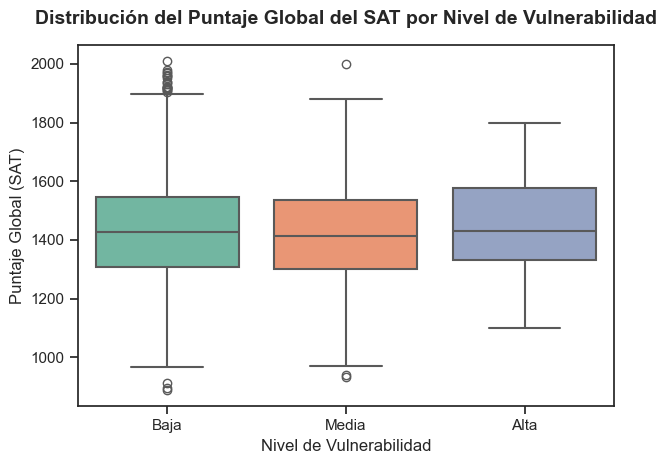


ANÁLISIS: PUNTAJE vs VULNERABILIDAD
La mediana del puntaje para el nivel de vulnerabilidad 'Baja' es: 1426.7
La mediana del puntaje para el nivel de vulnerabilidad 'Media' es: 1415.0
La mediana del puntaje para el nivel de vulnerabilidad 'Alta' es: 1429.7
--------------------------------------------------
Brecha detectada: Existe una diferencia de 14.7 puntos en las medianas entre el nivel más alto y el más bajo.
Conclusión: El gráfico de cajas confirma visualmente la disparidad en el rendimiento según el contexto socioeconómico / vulnerabilidad del centro educativo.


In [23]:
# Visualización con boxplot
plt.figure()
orden_vulnerabilidad = ['Baja', 'Media', 'Alta']
sns.boxplot(
    data=df_master, 
    x='Nivel_Vulnerabilidad', 
    y='Puntaje_Global', 
    order=orden_vulnerabilidad,
    palette='Set2',
    linewidth=1.5
)

plt.title('Distribución del Puntaje Global del SAT por Nivel de Vulnerabilidad', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nivel de Vulnerabilidad', fontsize=12)
plt.ylabel('Puntaje Global (SAT)', fontsize=12)
plt.tight_layout()
plt.show()

'''
Con el fin de exponer dinámicamente en Grafana, hemos optado por no mostrar .svgs de los gráficos por dicho medio, sin embargo, preservo la forma de generarlos.

try: 
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\boxplot_vulnerabilidad_rendimiento.svg'
    plt.savefig(ruta_guardado, format='svg')
except Exception :
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\notas\2026\Analisis de Datos\TPI - Intro al Analisis de Datos\repo\TPI-Analisis_de_Datos\graficos\boxplot_vulnerabilidad_rendimiento.svg'
    plt.savefig(ruta_guardado, format='svg')
'''

# Análisis Dinámico Automático
medianas = df_master.groupby('Nivel_Vulnerabilidad')['Puntaje_Global'].median()
print("\n" + "="*50)
print("ANÁLISIS: PUNTAJE vs VULNERABILIDAD")
print("="*50)
for nivel in orden_vulnerabilidad:
    if nivel in medianas:
        print(f"La mediana del puntaje para el nivel de vulnerabilidad '{nivel}' es: {medianas[nivel]:.1f}")

brecha = medianas.max() - medianas.min()
print("-" * 50)
print(f"Brecha detectada: Existe una diferencia de {brecha:.1f} puntos en las medianas entre el nivel más alto y el más bajo.")
print("Conclusión: El gráfico de cajas confirma visualmente la disparidad en el rendimiento según el contexto socioeconómico / vulnerabilidad del centro educativo.")

2. regplot(): Medida en que el nivel socioeconómico del distrito predice la brecha en los resultados en Matemática y Lectura comparando con el promedio estatal.

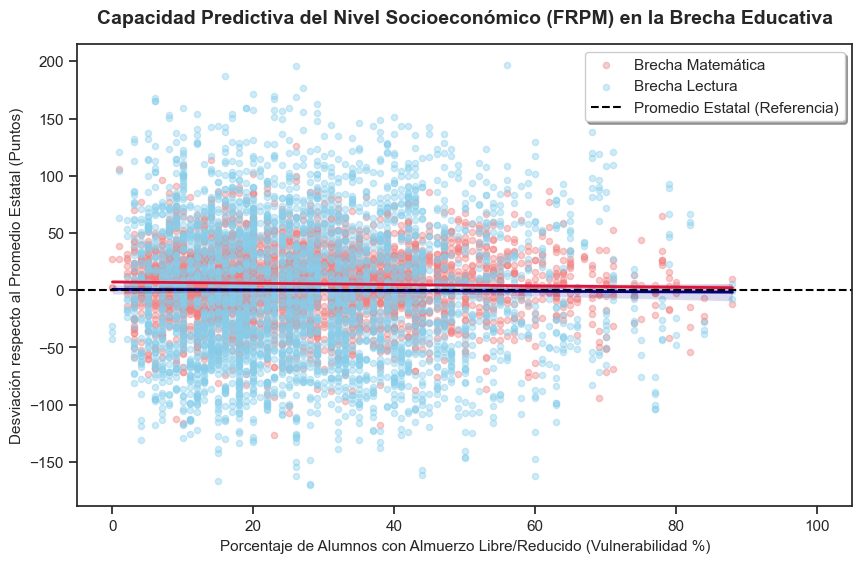

<Figure size 1200x700 with 0 Axes>

In [24]:
# Filtrado para trabajar únicamente con registros a nivel de Escuela ('S')
df_escuelas = df_master[df_master['rtype'] == 'S'].copy()

#Creación de Figura y Ejees.
fig, ax1 = plt.subplots(figsize=(10, 6))

# Crear la brecha restando los promedios
df_escuelas['Brecha_Matematica'] = df_escuelas['AvgScrMath'] - df_escuelas['AvgScrRead']

if df_escuelas['porcentaje_eligibilidad_comidas_gratuitas'].max() <= 1.0: # Verificación del formato de la columna FRPM
    df_escuelas['porcentaje_eligibilidad_comidas_gratuitas'] = df_escuelas['porcentaje_eligibilidad_comidas_gratuitas'] * 100


# Graficación la Brecha de Matemática (Puntos + Línea de tendencia)
sns.regplot(
    data=df_escuelas, 
    x='porcentaje_eligibilidad_comidas_gratuitas', 
    y='Brecha_Matematica', 
    scatter_kws={'alpha': 0.4, 's': 20},  # Transparencia y tamaño de los puntos
    line_kws={'color': 'crimson', 'linewidth': 2}, 
    label='Brecha Matemática',
    color='lightcoral'
)

df_escuelas['Brecha_Lectura'] = df_escuelas['AvgScrRead'] - df_escuelas['AvgScrRead'].mean()

# Graficación de la Brecha de Lectura (Puntos + Línea de tendencia)
sns.regplot(
    data=df_escuelas, 
    x='porcentaje_eligibilidad_comidas_gratuitas', 
    y='Brecha_Lectura', 
    scatter_kws={'alpha': 0.4, 's': 20}, 
    line_kws={'color': 'darkblue', 'linewidth': 2}, 
    label='Brecha Lectura',
    color='skyblue'
)

# Dibujo del "Cerrojo" del promedio estatal (Línea horizontal en Y = 0)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Promedio Estatal (Referencia)')

# Personalización y etiquetas profesionales
plt.title('Capacidad Predictiva del Nivel Socioeconómico (FRPM) en la Brecha Educativa', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Porcentaje de Alumnos con Almuerzo Libre/Reducido (Vulnerabilidad %)', fontsize=11)
plt.ylabel('Desviación respecto al Promedio Estatal (Puntos)', fontsize=11)

# Ajustae de los límites de los ejes para que quede limpio
plt.xlim(-5, 105) 
plt.legend(loc='upper right', frameon=True, shadow=True)

# Configuración del entorno estético del gráfico
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Mostrado del gráfico en pantalla
plt.tight_layout()
plt.show()

3. regplot(): Relación entre el tamaño de la clase y la mejora en las tasas de graduación en distritos considerados de riesgo.


MÉTRICA CORRELACIÓN DE PEARSON: 0.363



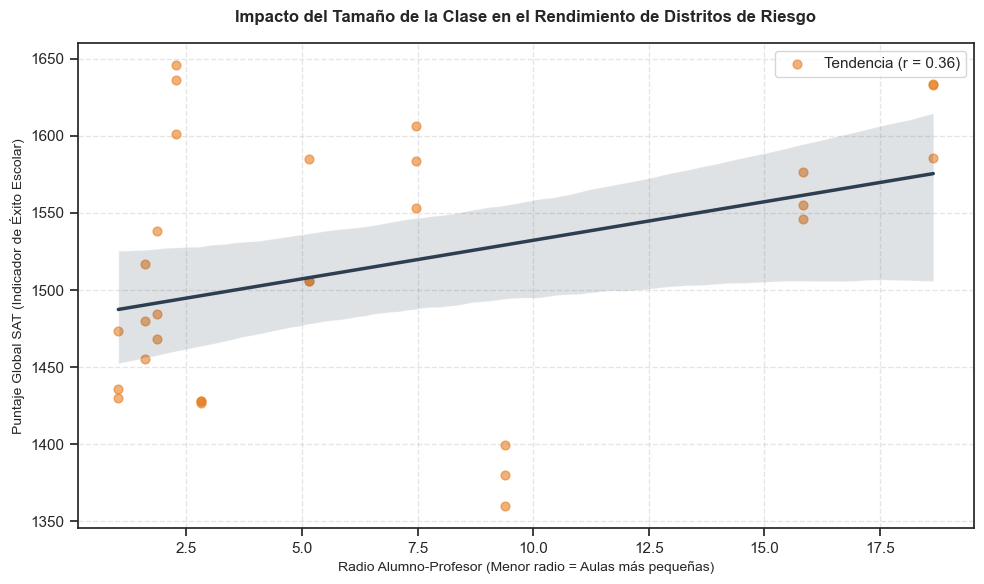

In [25]:
# Filtrar por Distritos ('D') que estén en situación de riesgo/alta vulnerabilidad
df_riesgo = df_master[(df_master['rtype'] == 'D') & (df_master['Nivel_Vulnerabilidad'] == 'Alta')].copy() # Esto aísla el análisis únicamente en el grupo de interés crítico

df_riesgo = df_riesgo.dropna(subset=['Radio_Alumno_Profesor', 'Puntaje_Global']) # Limpieza rápida por si existen distritos con datos faltantes en estas columnas

#  MEDIDA MATEMÁTICA: Calcular la correlación de Pearson
# El resultado estará entre -1 y 1. 
# Un valor negativo fuerte indica que a aulas más grandes (mayor ratio), tienen menor rendimiento.
correlacion = df_riesgo['Radio_Alumno_Profesor'].corr(df_riesgo['Puntaje_Global'])
print("\n========================================================")
print(f"MÉTRICA CORRELACIÓN DE PEARSON: {correlacion:.3f}") #Medida estadística que cuantifica la fuerza y la dirección de la relación lineal entre 2 variables cuantitativas.
print("========================================================\n")

# CONSTRUCCIÓN DEL GRÁFICO DE DISPERSIÓN + REGRESIÓN
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")

sns.regplot(
    data=df_riesgo,
    x='Radio_Alumno_Profesor',
    y='Puntaje_Global',
    scatter_kws={'alpha': 0.6, 'color': '#e67e22', 's': 40}, # Naranja para los distritos
    line_kws={'color': '#2c3e50', 'linewidth': 2.5},         # Línea de tendencia oscura
    label=f'Tendencia (r = {correlacion:.2f})'
)

# Personalización del gráfico
plt.title('Impacto del Tamaño de la Clase en el Rendimiento de Distritos de Riesgo', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Radio Alumno-Profesor (Menor radio = Aulas más pequeñas)', fontsize=10)
plt.ylabel('Puntaje Global SAT (Indicador de Éxito Escolar)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

4. (scatter plot y barplot) Identificación de distritos con alta vulnerabilidad demográfica que superan las expectativas de rendimiento y demostración de patrones en sus datos.

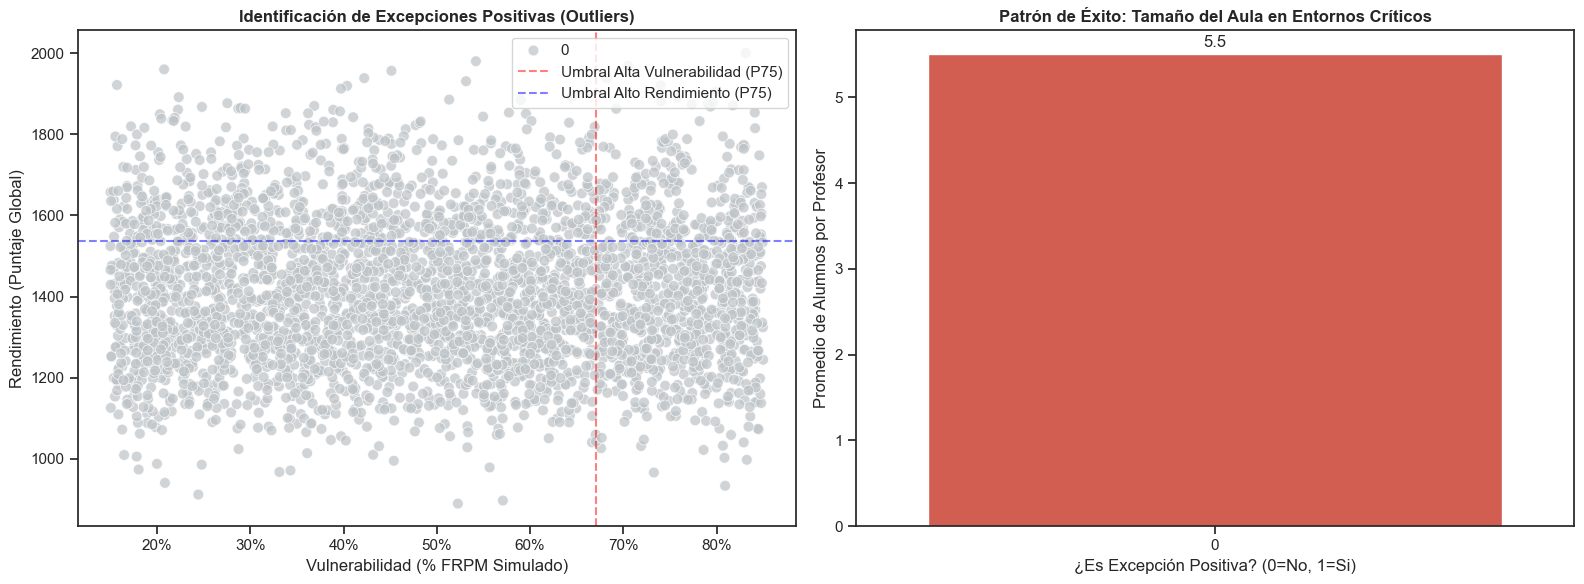

In [26]:
import matplotlib.ticker as mtick

# Filtrado solo de Escuelas y asegurar el tipo de dato.
df_escuelas = df_master[df_master['rtype'] == 'S'].copy()
df_escuelas['Excepcion_Positiva'] = df_escuelas['Excepcion_Positiva'].astype(int)

# Recuperar los umbrales (percentil 75)
umbral_vuln = df_escuelas['frpm_simulado'].quantile(0.75)
umbral_rend = df_escuelas['Puntaje_Global'].quantile(0.75)

# Configurar la figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Paletas de colores binarias con claves numéricas (enteros)
paleta_colores_scatter = {1: '#27ae60', 0: '#bdc3c7'}
paleta_colores_bar = {1: '#27ae60', 0: '#e74c3c'}

# ====================================================================
# GRÁFICO 1: EL MAPA DE CUADRANTES (SCATTER PLOT)
# ====================================================================
sns.scatterplot(
    data=df_escuelas, 
    x='frpm_simulado', 
    y='Puntaje_Global', 
    hue='Excepcion_Positiva', 
    palette=paleta_colores_scatter, 
    alpha=0.7,
    s=60,
    ax=ax1
)

ax1.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Dibujar las líneas de los umbrales
ax1.axvline(umbral_vuln, color='red', linestyle='--', alpha=0.5, label='Umbral Alta Vulnerabilidad (P75)')
ax1.axhline(umbral_rend, color='blue', linestyle='--', alpha=0.5, label='Umbral Alto Rendimiento (P75)')

ax1.set_title('Identificación de Excepciones Positivas (Outliers)', fontweight='bold')
ax1.set_xlabel('Vulnerabilidad (% FRPM Simulado)')
ax1.set_ylabel('Rendimiento (Puntaje Global)')
ax1.legend(loc='upper right')

# ====================================================================
# GRÁFICO 2: EL PATRÓN DE ÉXITO (BAR PLOT)
# ====================================================================

df_critico = df_escuelas[df_escuelas['frpm_simulado'] >= umbral_vuln].copy()

sns.barplot(
    data=df_critico, 
    x='Excepcion_Positiva', 
    y='Radio_Alumno_Profesor', 
    hue='Excepcion_Positiva', # <-- Mapeo por tipo de dato numérico
    palette=paleta_colores_bar, 
    legend=False,             # <-- Oculta la leyenda extra para que quede estético
    errorbar=None, 
    ax=ax2
)

ax2.set_title('Patrón de Éxito: Tamaño del Aula en Entornos Críticos', fontweight='bold')
ax2.set_xlabel('¿Es Excepción Positiva? (0=No, 1=Si)')
ax2.set_ylabel('Promedio de Alumnos por Profesor')

# Agregar los valores sobre las barras
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

- barplots() agrupados para ver el desempeño por sección academica de los alumnos.

<>:36: SyntaxWarning: invalid escape sequence '\P'
<>:36: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Admin\AppData\Local\Temp\ipykernel_9576\3687625590.py:36: SyntaxWarning: invalid escape sequence '\P'
  ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\barplot_rendimiento_seccion.svg'


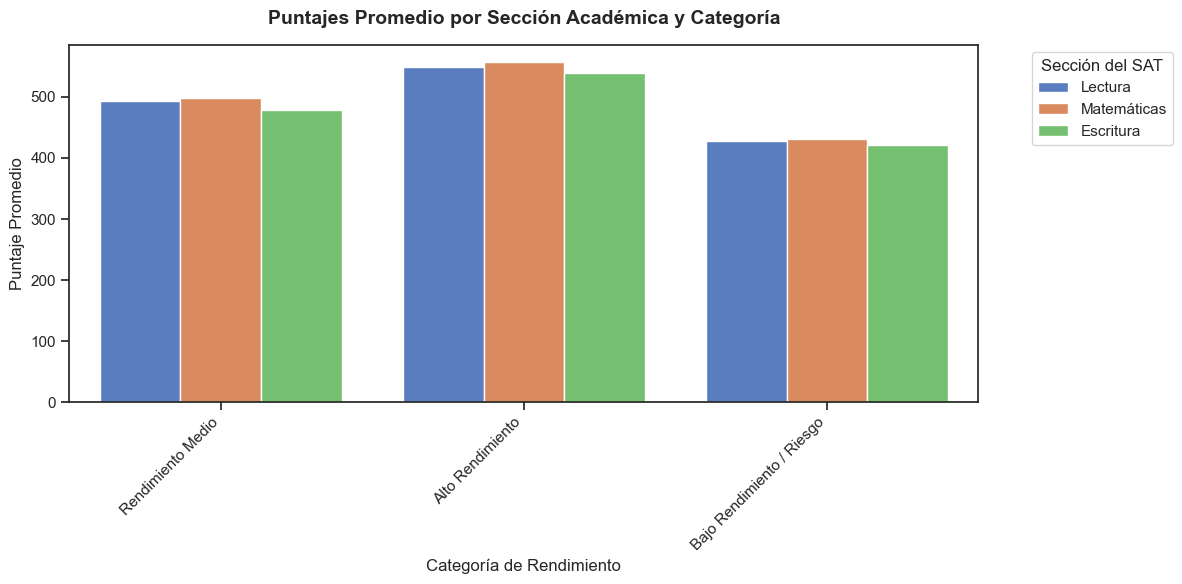


ANÁLISIS: DESEMPEÑO POR SECCIÓN
A nivel general del dataset:
- La materia con MEJOR desempeño promedio es: Matemáticas (482.2 pts)
- La materia con PEOR desempeño promedio es: Escritura (468.1 pts)
--------------------------------------------------
Las proporciones entre materias se mantienen constantes a través de las diferentes categorías de escuelas,
operando como bloques uniformes de aumento o disminución.


In [27]:
# Preparar datos: Derretir (melt) el dataframe para usar seaborn hue fácilmente
secciones = ['AvgScrRead', 'AvgScrMath', 'AvgScrWrit']
df_melted = df_master.melt(id_vars=['Categoria_Rendimiento'], value_vars=secciones, var_name='Seccion', value_name='Puntaje_Promedio')

# Mapear nombres para la leyenda
mapeo_secciones = {'AvgScrRead': 'Lectura', 'AvgScrMath': 'Matemáticas', 'AvgScrWrit': 'Escritura'}
df_melted['Seccion'] = df_melted['Seccion'].map(mapeo_secciones)

# 3. Visualización: Gráfico de Barras Agrupadas
# Aumentamos un poco el ancho de la figura a 12 para dar más espacio a las barras
plt.figure(figsize=(12, 6)) 
sns.barplot(
    data=df_melted, 
    x='Categoria_Rendimiento', 
    y='Puntaje_Promedio', 
    hue='Seccion', 
    palette='muted',
    errorbar=None # Ocultar barras de error para mayor limpieza
)

plt.title('Puntajes Promedio por Sección Académica y Categoría', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoría de Rendimiento', fontsize=12)
plt.ylabel('Puntaje Promedio', fontsize=12)
plt.legend(title='Sección del SAT', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- SOLUCIÓN AL OVERLAPPING ---
# Rotamos las etiquetas del eje X 45 grados y las alineamos a la derecha para una lectura perfecta
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

'''
try: 
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\barplot_rendimiento_seccion.svg'
    plt.savefig(ruta_guardado, format='svg')
except Exception :
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\notas\2026\Analisis de Datos\TPI - Intro al Analisis de Datos\repo\TPI-Analisis_de_Datos\graficos\barplot_rendimiento_seccion.svg'
    plt.savefig(ruta_guardado, format='svg')
'''

# Análisis Dinámico Automático
medias_secciones = df_master[secciones].mean()
seccion_max = mapeo_secciones[medias_secciones.idxmax()]
seccion_min = mapeo_secciones[medias_secciones.idxmin()]


print("\n" + "="*50)
print("ANÁLISIS: DESEMPEÑO POR SECCIÓN")
print("="*50)
print("A nivel general del dataset:")
print(f"- La materia con MEJOR desempeño promedio es: {seccion_max} ({medias_secciones.max():.1f} pts)")
print(f"- La materia con PEOR desempeño promedio es: {seccion_min} ({medias_secciones.min():.1f} pts)")
print("-" * 50)
print("Las proporciones entre materias se mantienen constantes a través de las diferentes categorías de escuelas,\noperando como bloques uniformes de aumento o disminución.")

- histplot() para mostrar el radio de rendimiento de las escuelas por la participación.

<>:35: SyntaxWarning: invalid escape sequence '\P'
<>:35: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Admin\AppData\Local\Temp\ipykernel_9576\3584199455.py:35: SyntaxWarning: invalid escape sequence '\P'
  ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\histplot_rendimiento_participacion.svg'


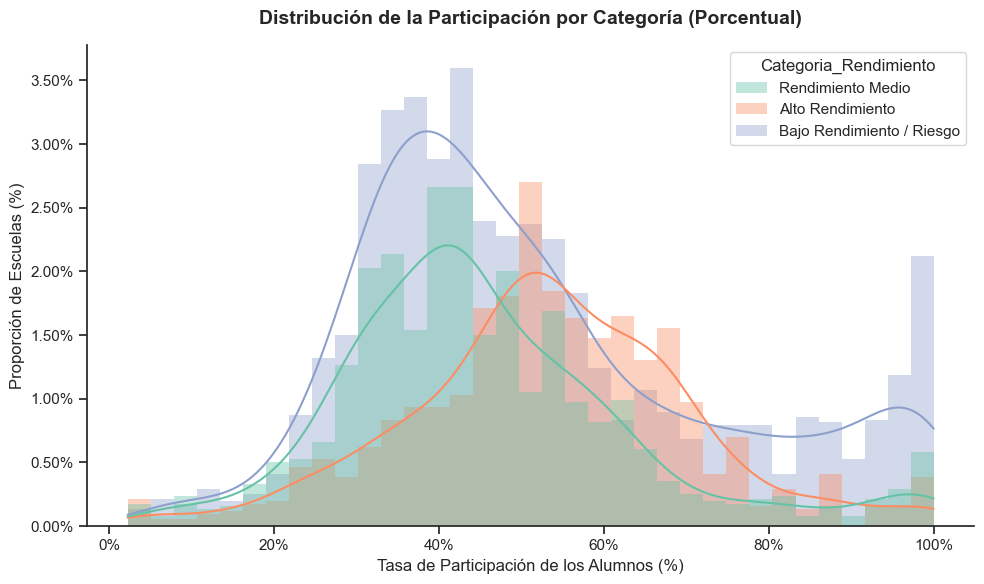


ANÁLISIS: DISTRIBUCIÓN PORCENTUAL DE PARTICIPACIÓN
El eje Y ahora representa el porcentaje real de instituciones.
Los picos del histograma indican dónde se agrupa el mayor porcentaje de escuelas para cada categoría de rendimiento.


In [19]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_master, 
    x='Tasa_Participacion', 
    hue='Categoria_Rendimiento', 
    stat='percent',      # Convierte el eje Y en porcentajes reales
    common_norm=True,   # El 100% se calcula dentro de cada categoría, no sobre el total mezclado
    kde=True,            # Mantiene la curva de tendencia superpuesta
    palette='Set2', 
    alpha=0.4,
    linewidth=0          # Elimina el borde de las barras para que se vea más limpio
)

plt.title('Distribución de la Participación por Categoría (Porcentual)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tasa de Participación de los Alumnos (%)', fontsize=12)
plt.ylabel('Proporción de Escuelas (%)', fontsize=12)

# Formateamos ambos ejes con el símbolo de porcentaje (%)
# El eje X asume que tus datos van de 0 a 100
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
# El eje Y ahora también va de 0 a 100 gracias a stat='percent'
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))

sns.despine()
plt.tight_layout()
plt.show()


'''
try:
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\Program Files\GrafanaLabs\grafana\public\img\graficos\histplot_rendimiento_participacion.svg'
    plt.savefig(ruta_guardado, format='svg')
except Exception :
    #'r' antes de las comillas para guardar el gráfico sin complicaciones.
    ruta_guardado = r'C:\notas\2026\Analisis de Datos\TPI - Intro al Analisis de Datos\repo\TPI-Analisis_de_Datos\graficos\histplot_rendimiento_participacion.svg'
    plt.savefig(ruta_guardado, format='svg')
'''

# Análisis Dinámico Automático
print("\n" + "="*50)
print("ANÁLISIS: DISTRIBUCIÓN PORCENTUAL DE PARTICIPACIÓN")
print("="*50)
print("El eje Y ahora representa el porcentaje real de instituciones.")
print("Los picos del histograma indican dónde se agrupa el mayor porcentaje de escuelas para cada categoría de rendimiento.")

In [ ]:
# Bloque de diagnóstico
registro_filtrado = df_clean[(df_clean['rtype'] == 'D') & (df_clean['Radio_Alumno_Profesor'] > 100)]
print(f"Cantidad de distritos con radio > 100: {len(registro_filtrado)}")
if not registro_filtrado.empty:
    print(registro_filtrado[['rtype', 'dname', 'enroll12', 'profes_simulado', 'Radio_Alumno_Profesor']].head())

Cantidad de distritos con radio > 100: 0
